Lab 1: week of September 14
*  claim a dataset
*  exploratory analysis
*  define target, frequency, and horizon

Claimed dataset is "Bike Sharing Capital"


In [28]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

#Data Loading
Our dataset is called Bike Sharing and contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information. It consists of 13 features and 17389 rows. The features are either integers or real numbers.

In [29]:
#load dataset and show the first 5 rows
df = pd.read_csv('day.csv')
df.head()



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [30]:
df2 = pd.read_csv('hour.csv')
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


We have a decision to make: do we use the hourly dataset or the day dataset?
After plotting both, hourly data is very dense. It is hard to see patterns. It would need to be resampled anyway. Maybe our resampling rule should be "go with day to day" rather than hourly.

In [31]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Actually need to verify is any value is missing.
We have a regular index.

In [32]:
print("Missing Values for Daily Data Set:")
print(df.isna().sum())

Missing Values for Daily Data Set:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [33]:
print("Missing Values for Hourly Data Set:")
print(df2.isna().sum())

Missing Values for Hourly Data Set:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Great news: there are no missing values.
However, there is a large difference in # of rows depending on if we choose to include hr data or not.


Below is code to get a column called date of datetime type. Datetime objects are python objects that contain all the information of both a date object and a time object. Year, month, day are necessary and hr is the most amount of time data we have.

In [34]:
df = df.rename(columns={'dteday': 'date'})
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
date,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [38]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [58]:
#.astype() casts argument to a specified dtype
# therefore, hr goes from numeric to string type before being added to datetime object
df2['date'] = pd.to_datetime(df2['dteday'] + ' ' + df2['hr'].astype(str) + ':00:00')
#df2['date'] = pd.to_datetime(df2['dteday'])
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,date
date,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2011-01-01 00:00:00
2011-01-01 01:00:00,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,2011-01-01 01:00:00
2011-01-01 02:00:00,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2011-01-01 02:00:00
2011-01-01 03:00:00,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2011-01-01 03:00:00
2011-01-01 04:00:00,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,2011-01-01 04:00:00


In [40]:
# explore statistics of data
df2.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,date
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088,2012-01-02 15:41:22.858622464
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2011-01-01 00:00:00
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,2011-07-04 22:30:00
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,2012-01-02 21:00:00
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,2012-07-02 06:30:00
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,2012-12-31 23:00:00
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599,NaN


Descriptive statistics show no missing values.

A lot of these columns are categorical though.

In [41]:
# make another version of df where date is the index
df2 = df2.set_index('date')

Now the head will show date as the index

In [42]:
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
date,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2011-01-01 01:00:00,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2011-01-01 02:00:00,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
2011-01-01 03:00:00,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
2011-01-01 04:00:00,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [48]:
cnt_data_daily = df['cnt']
cnt_data_daily.head()

date
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
Name: cnt, dtype: int64

Below is a plot of this data so we can visualize it raw.

In [49]:
cnt_data_hourly = df2['cnt']
cnt_data_hourly.head()

date
2011-01-01 00:00:00    16
2011-01-01 01:00:00    40
2011-01-01 02:00:00    32
2011-01-01 03:00:00    13
2011-01-01 04:00:00     1
Name: cnt, dtype: int64

<Axes: xlabel='date', ylabel='cnt'>

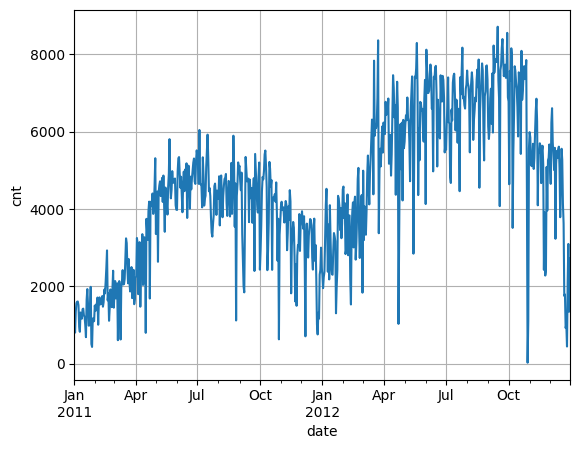

In [53]:
cnt_data_daily.plot(ylabel='cnt',grid=True)

<Axes: xlabel='date', ylabel='cnt'>

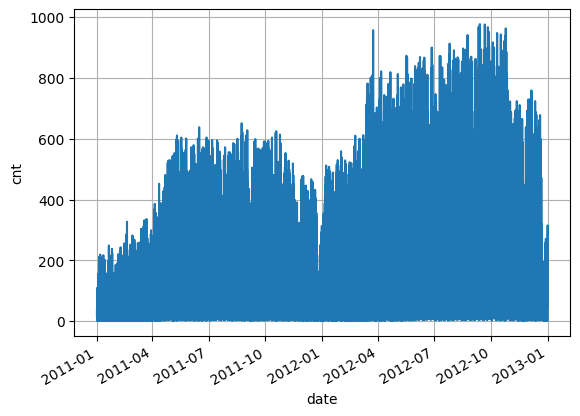

In [52]:
cnt_data_hourly.plot(ylabel='cnt',grid=True)

**Plot for Daily Bike Count for January**

<Axes: xlabel='date', ylabel='cnt'>

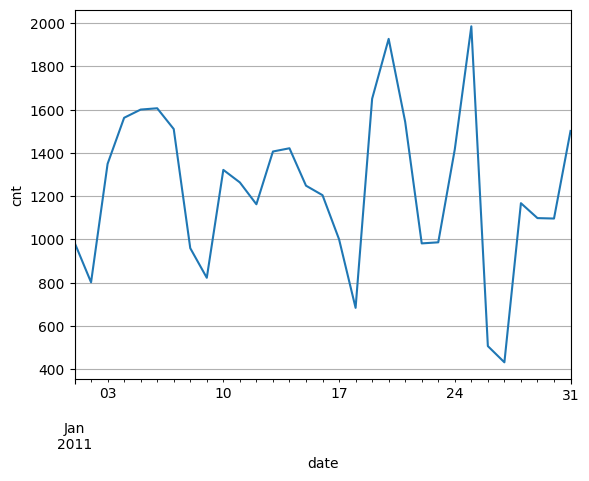

In [57]:
df_2011 = df.loc['2011-01']
cnt_Ddata_2011 = df_2011['cnt']
cnt_Ddata_2011.plot(ylabel='cnt',grid=True)

**Plot for Hourly Bike Count on January 1st, 2011**

<Axes: xlabel='date', ylabel='cnt'>

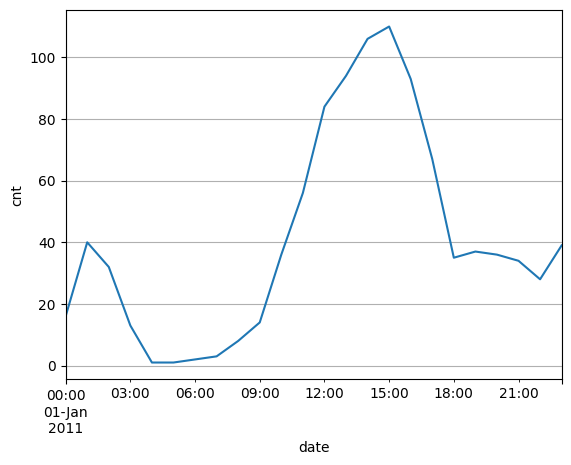

In [55]:
df2_2011 = df2.loc['2011-01-01']
cnt_Hdata_2011 = df2_2011['cnt']
cnt_Hdata_2011.plot(ylabel='cnt',grid=True)

<Axes: xlabel='date'>

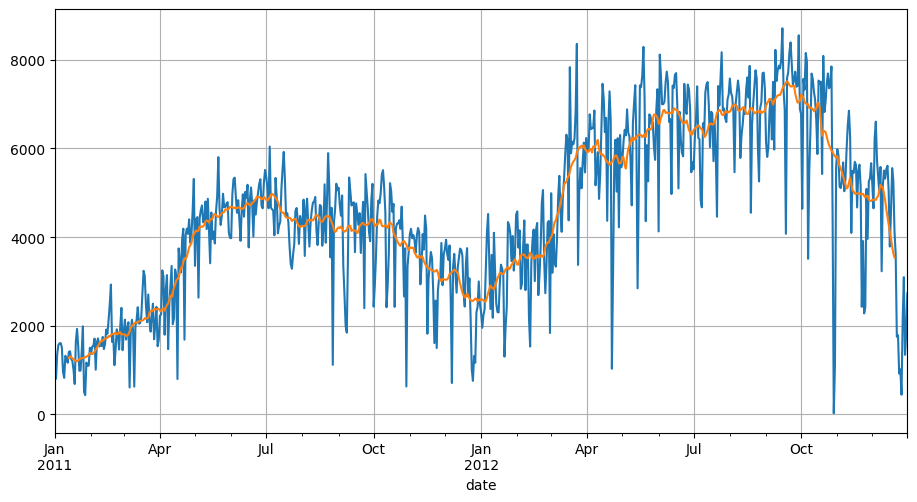

In [70]:
#use a simple rolling 24 average transformation to see trend and seasonality
from numpy.strings import center
trend_24 = cnt_data_daily.rolling(24, center=True).mean()

fig, ax = plt.subplots(figsize=(11,5.5))
cnt_data_daily.plot(ax=ax, label='Daily')
trend_24.plot(ax=ax, label='24-day moving avg',grid=True)

The orange line is the 24-day moving average, while the blue line shows the actual daily bike counts. The moving average is smoother with less noise, making it easier to see overall trends and seasonal changes in bike rentals.

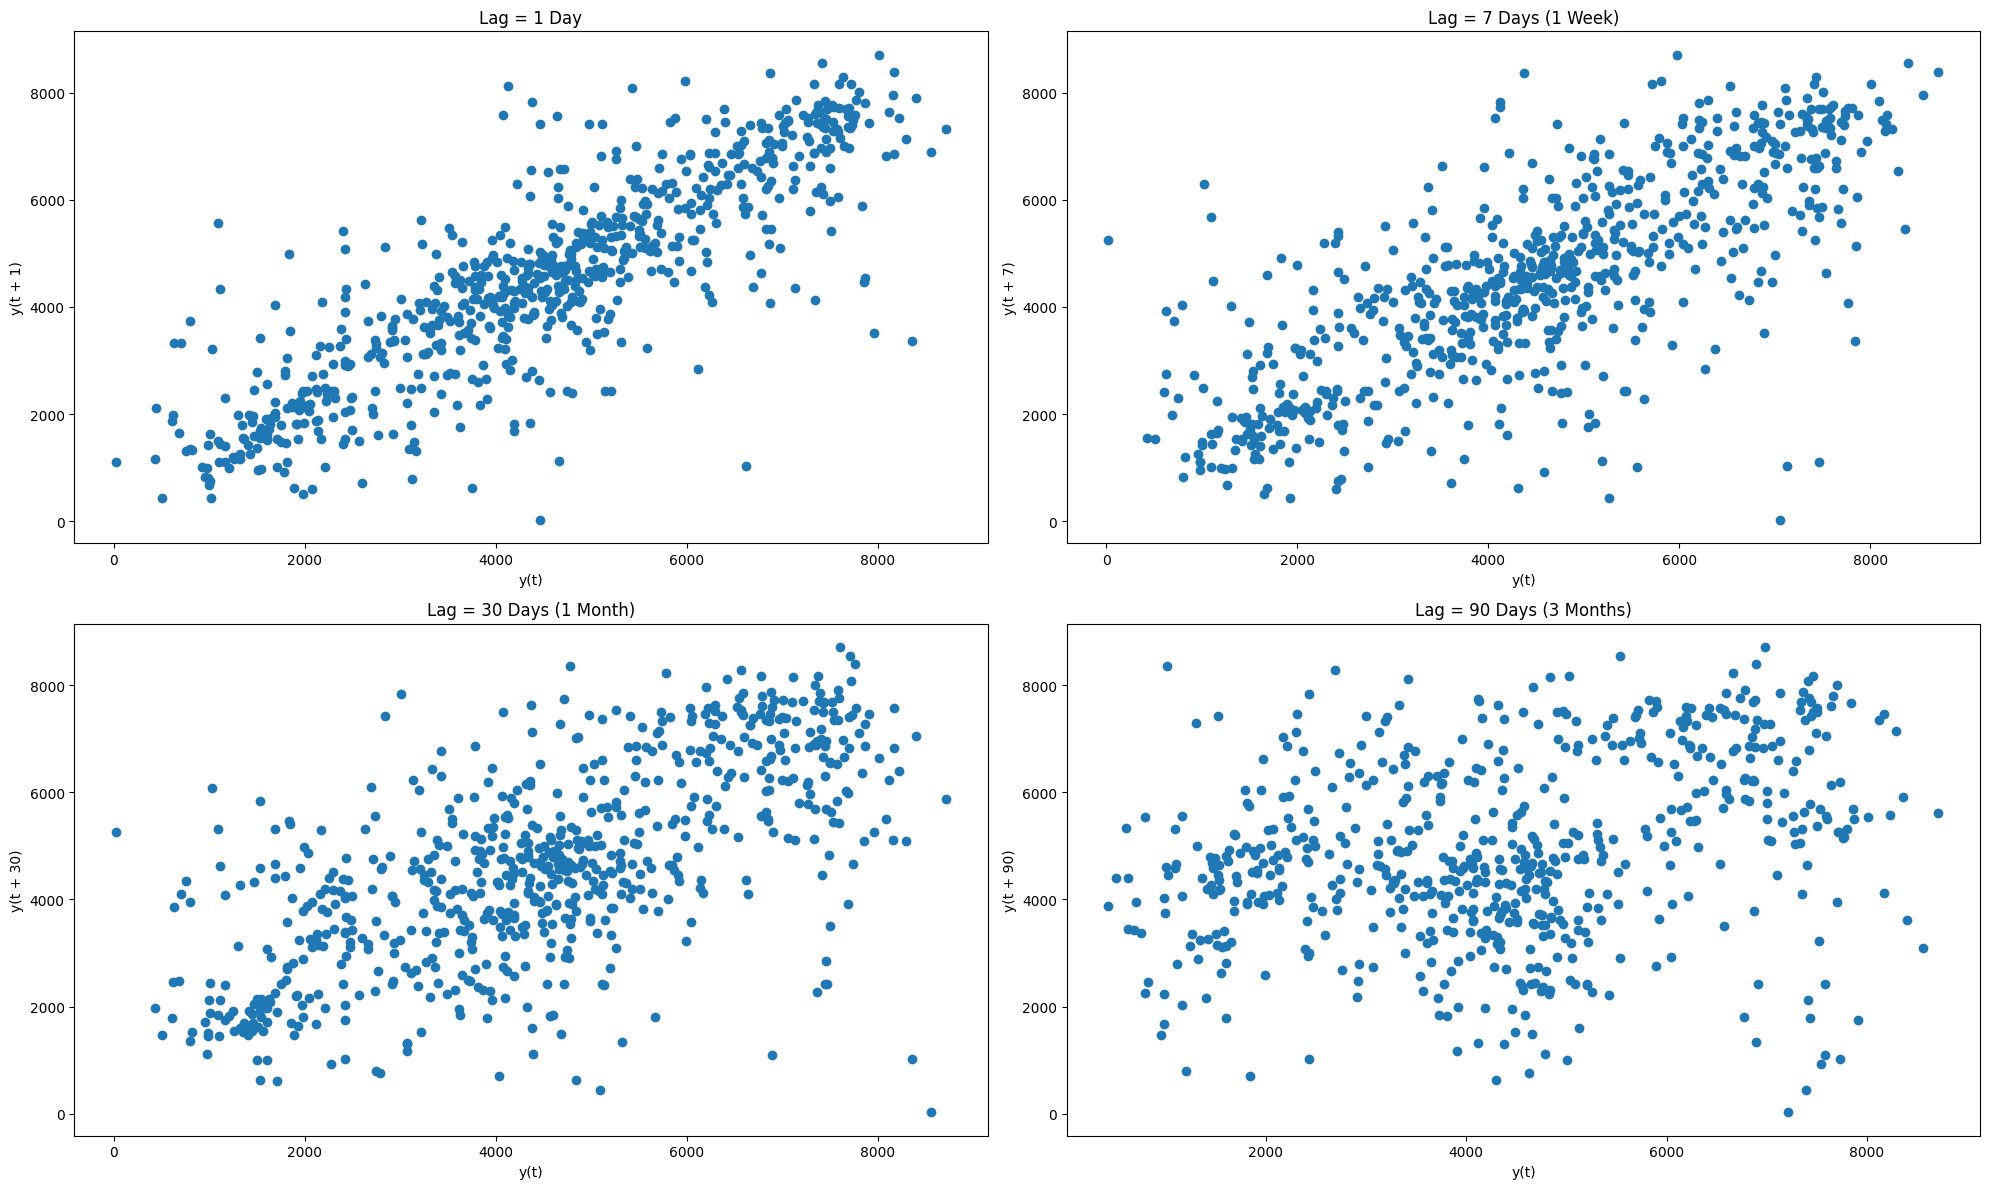

In [73]:
# Create space for the 4 graphs
plt.figure(figsize=(20, 12))

# 1 Day
plt.subplot(2, 2, 1)
pd.plotting.lag_plot(df['cnt'], lag=1)
plt.title('Lag = 1 Day')

# 1 Week
plt.subplot(2, 2, 2)
pd.plotting.lag_plot(df['cnt'], lag=7)
plt.title('Lag = 7 Days (1 Week)')

# 1 month
plt.subplot(2, 2, 3)
pd.plotting.lag_plot(df['cnt'], lag=30)
plt.title('Lag = 30 Days (1 Month)')

# 3 Months
plt.subplot(2, 2, 4)
pd.plotting.lag_plot(df['cnt'], lag=90)
plt.title('Lag = 90 Days (3 Months)')

# Prevent graphs from overlapping
plt.tight_layout()

# Display graphs
plt.show()

Based off the graphs, 1-day and 7-day lags show strong positive dependence. Much more scattered and dispersed and 30 days and basically nonexistent at 3 months. L of maybe 1 or 7??

<Axes: >

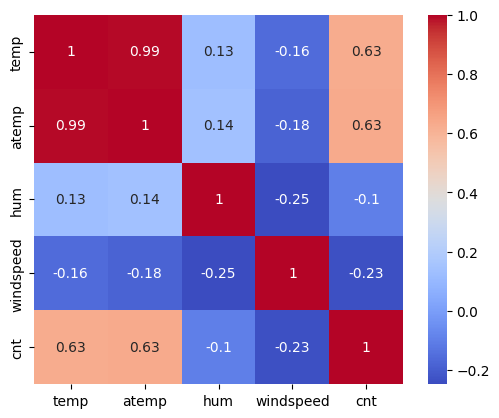

In [75]:
# Correlation Analysis
df_corr_vals = df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
df_corr_vals

# Correlation Heatmap
sns.heatmap(df_corr_vals, square=True, annot=True, cmap='coolwarm')

**Strongest Positive Relationships**

temp --> cnt: 0.63 --> warmer temperature = generally more bike rentals<br>
atemp --> cnt: 0.63 --> warmer temperature = generally more bike rentals <br>
temp --> atemp: 0.99 (atemp and temp are basically the same thing)

**Strongest Negative Relationships**

windspeed --> cnt: -0.23 = higher windspeed is linked to fewer bike rentals<br>
humidity --> windspeed: -0.25 = humidity increases, windpseeds tends to decrease


Need to decide on a look back horizon before modelling.

**What is our target?** how far into the future

**What will our input be?** how far into the past will we use?

Once we decide L and h we can determine our windows.

**What is our forecasting goal?** what questions do we want to be able to answer with our forecasting tool? Predict number of users next year? or predict number of users on a rainy day?

Summary of Dataset
*   it is multivariate
*   sampling is regular, each day. no missed values bc of the sensors.
*   there is seasonality
*   List item

Questions:
*  can we use categorical data?
*   List item





